# TT-05 — SVM: Phân loại khối u lành tính / ác tính
Bộ dữ liệu: Breast Cancer Wisconsin (Diagnostic) — nạp từ file gốc `wdbc.data`
đi kèm bài nộp (không dùng `sklearn.datasets.load_breast_cancer`), để dữ liệu
commit và dữ liệu huấn luyện là **một nguồn duy nhất, nhất quán**.

 Quy ước nhãn: **0 = ác tính (malignant), 1 = lành tính (benign)**. Nhãn gốc
trong `wdbc.data` là `M`/`B`, được ánh xạ tường minh sang `0`/`1` bên dưới và
in ra để xác nhận — không dựa vào quy ước ngầm của một dataset nạp sẵn.

Mục tiêu chính: **recall lớp ác tính cao nhất có thể trên tập test giữ lại**,
đo một cách trung thực (không dò ngưỡng/tham số trên chính tập test).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (recall_score, precision_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report, roc_auc_score,
                              make_scorer, fbeta_score)

RANDOM_STATE = 42
plt.rcParams['figure.figsize'] = (6, 4)

# Đường dẫn xuất file phải đúng bất kể notebook được chạy từ cwd nào
# (fix lỗi cũ: '../reports/...' ghi ra ngoài thư mục bài nếu chạy sai cwd)
NOTEBOOK_DIR = Path.cwd()
ROOT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
REPORTS_DIR = ROOT_DIR / 'reports'
MODELS_DIR = ROOT_DIR / 'models'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print('ROOT_DIR   =', ROOT_DIR)
print('REPORTS_DIR=', REPORTS_DIR)
print('MODELS_DIR =', MODELS_DIR)

ROOT_DIR   = d:\Tai_lieu_hoc_AI\NOP_BAI_LAB_ML\Hoc may\01- Phan loai\TT - 05
REPORTS_DIR= d:\Tai_lieu_hoc_AI\NOP_BAI_LAB_ML\Hoc may\01- Phan loai\TT - 05\reports
MODELS_DIR = d:\Tai_lieu_hoc_AI\NOP_BAI_LAB_ML\Hoc may\01- Phan loai\TT - 05\models


## Bước 1 — Nạp dữ liệu từ `wdbc.data`, xác nhận quy ước nhãn

Fix lỗi cũ: cell nạp dữ liệu từng dùng `X, y` **trước khi gán** (`X.shape` gọi trước khi `X` tồn tại) → `NameError` nếu chạy lại notebook từ đầu. Ở đây `X`, `y` được tạo và dùng ngay trong cùng một cell.

In [4]:
# Thứ tự cột theo wdbc.names: id, diagnosis, rồi 10 đặc trưng gốc x 3 thống kê (mean, se, worst)
FEATURE_BASES = ['radius', 'texture', 'perimeter', 'area', 'smoothness',
                  'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension']
STATS = ['mean', 'se', 'worst']
COLS = ['id', 'diagnosis'] + [f'{b}_{s}' for s in STATS for b in FEATURE_BASES]

raw = pd.read_csv(ROOT_DIR / 'wdbc.data', header=None, names=COLS)

target_names = ['malignant', 'benign']  # index 0, 1
y = raw['diagnosis'].map({'M': 0, 'B': 1})   # ánh xạ TƯỜNG MINH: 0 = ác tính, 1 = lành tính
X = raw.drop(columns=['id', 'diagnosis'])

assert y.isna().sum() == 0, "Có nhãn không map được — kiểm tra lại file wdbc.data"

print("Số dòng, số cột:", X.shape)
print("target_names:", target_names)
print(y.value_counts())
print()
print("=> Xác nhận: giá trị 0 tương ứng '%s' (ÁC TÍNH), giá trị 1 tương ứng '%s' (LÀNH TÍNH)"
      % (target_names[0], target_names[1]))

Số dòng, số cột: (569, 30)
target_names: ['malignant', 'benign']
diagnosis
1    357
0    212
Name: count, dtype: int64

=> Xác nhận: giá trị 0 tương ứng 'malignant' (ÁC TÍNH), giá trị 1 tương ứng 'benign' (LÀNH TÍNH)


## Bước 2 — EDA: heatmap tương quan 30 biến

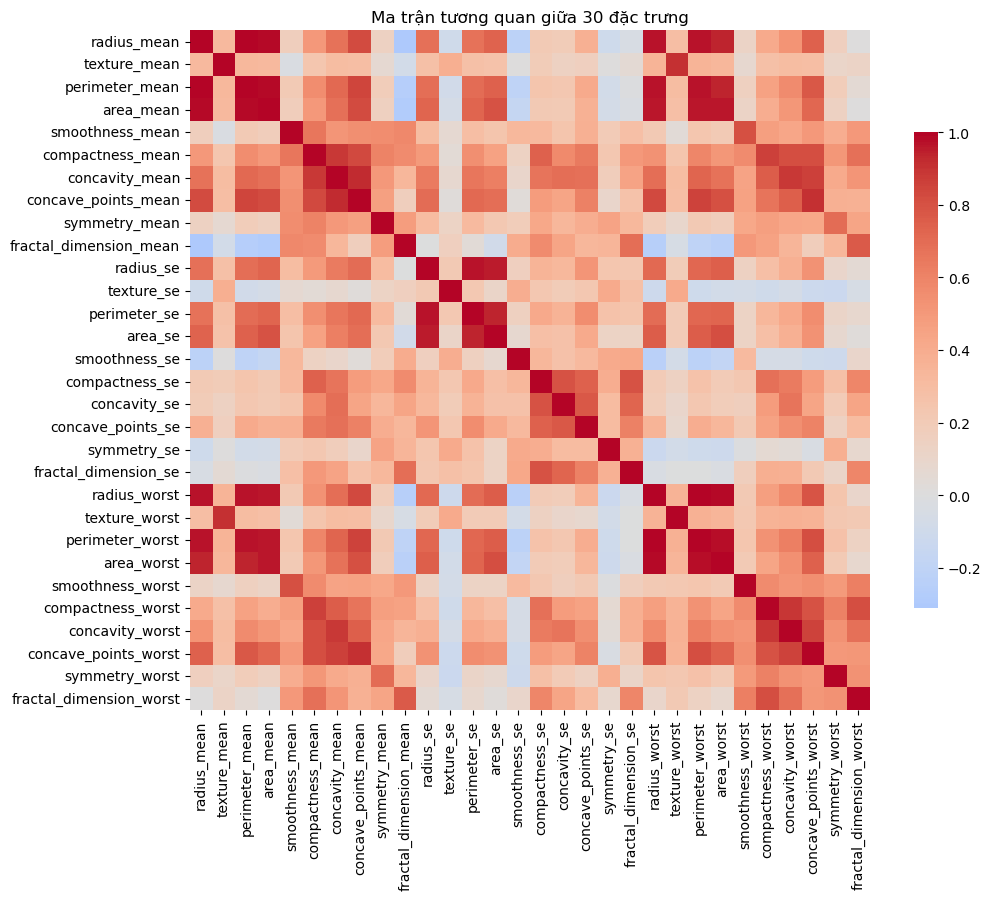

Số cặp biến tương quan > 0.95: 15
  radius_mean  <->  radius_worst   corr=0.970
  perimeter_mean  <->  radius_mean   corr=0.998
  perimeter_mean  <->  radius_worst   corr=0.969
  perimeter_mean  <->  perimeter_worst   corr=0.970
  area_mean  <->  radius_mean   corr=0.987
  area_mean  <->  perimeter_mean   corr=0.987
  area_mean  <->  radius_worst   corr=0.963
  area_mean  <->  perimeter_worst   corr=0.959
  area_mean  <->  area_worst   corr=0.959
  perimeter_se  <->  radius_se   corr=0.973


In [5]:
corr = X.corr()  # tính ma trận tương quan giữa các đặc trưng
plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.7})
plt.title("Ma trận tương quan giữa 30 đặc trưng")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "correlation_heatmap.png", dpi=120)
plt.show()

# Các cặp tương quan rất mạnh (|corr| > 0.95, khác biến)
strong = (corr.abs() > 0.95) & (corr.abs() < 1.0)
pairs = [(i, j) for i in corr.columns for j in corr.columns
         if strong.loc[i, j] and i < j]
print(f"Số cặp biến tương quan > 0.95: {len(pairs)}")
for i, j in pairs[:10]:
    print(f"  {i}  <->  {j}   corr={corr.loc[i,j]:.3f}")

**Nhận xét:** như dự kiến, `radius_mean`, `perimeter_mean`, `area_mean` (và các
biến `worst` tương ứng) tương quan gần như tuyệt đối vì cùng đo kích thước khối u
theo 3 cách khác nhau. Đây là hiện tượng đa cộng tuyến — không gây lỗi cho SVM
(SVM không cần các biến độc lập tuyến tính như hồi quy), nhưng cho thấy 30 biến
mang ít thông tin độc lập hơn con số 30 gợi ý.

## Bước 3 — Chia train/test (stratify)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Tỉ lệ lớp train:\n", y_train.value_counts(normalize=True))
print("Tỉ lệ lớp test:\n", y_test.value_counts(normalize=True))

Train: (455, 30)  Test: (114, 30)
Tỉ lệ lớp train:
 diagnosis
1    0.626374
0    0.373626
Name: proportion, dtype: float64
Tỉ lệ lớp test:
 diagnosis
1    0.631579
0    0.368421
Name: proportion, dtype: float64


## Bước 4 — SVM KHÔNG chuẩn hoá (baseline)

In [7]:
svm_noscale = SVC(kernel='rbf', random_state=RANDOM_STATE)
svm_noscale.fit(X_train, y_train)
pred_noscale = svm_noscale.predict(X_test)

recall_noscale = recall_score(y_test, pred_noscale, pos_label=0)
precision_noscale = precision_score(y_test, pred_noscale, pos_label=0)

print("KHÔNG scale — recall(ác tính):", round(recall_noscale, 3))
print("KHÔNG scale — precision(ác tính):", round(precision_noscale, 3))
print()
print(classification_report(y_test, pred_noscale, target_names=['malignant(0)', 'benign(1)']))

KHÔNG scale — recall(ác tính): 0.857
KHÔNG scale — precision(ác tính): 0.947

              precision    recall  f1-score   support

malignant(0)       0.95      0.86      0.90        42
   benign(1)       0.92      0.97      0.95        72

    accuracy                           0.93       114
   macro avg       0.93      0.91      0.92       114
weighted avg       0.93      0.93      0.93       114



## Bước 5 — SVM CÓ chuẩn hoá (Pipeline) — so sánh với Bước 4

`StandardScaler` luôn nằm **trong `Pipeline`** để scaler chỉ được `fit` trên dữ liệu train của mỗi lần huấn luyện/CV — tránh rò rỉ thông tin từ test/validation vào bước chuẩn hoá.

CÓ scale — recall(ác tính): 0.976
CÓ scale — precision(ác tính): 0.976

             recall_ác_tính  precision_ác_tính
Không scale        0.857143           0.947368
Có scale           0.976190           0.976190


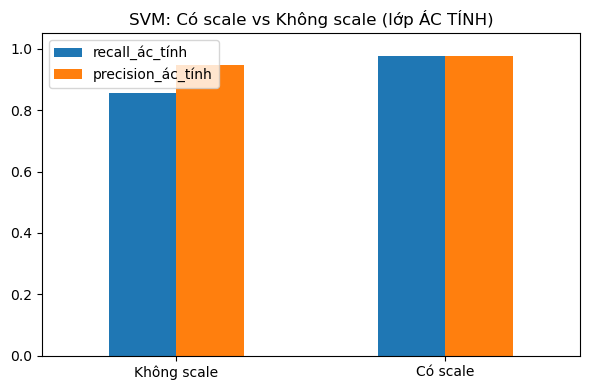

In [8]:
pipe_scale = Pipeline([
    ('scale', StandardScaler()),
    ('svm', SVC(kernel='rbf', random_state=RANDOM_STATE))
])
pipe_scale.fit(X_train, y_train)
pred_scale = pipe_scale.predict(X_test)

recall_scale = recall_score(y_test, pred_scale, pos_label=0)
precision_scale = precision_score(y_test, pred_scale, pos_label=0)

print("CÓ scale — recall(ác tính):", round(recall_scale, 3))
print("CÓ scale — precision(ác tính):", round(precision_scale, 3))

compare_df = pd.DataFrame({
    'recall_ác_tính': [recall_noscale, recall_scale],
    'precision_ác_tính': [precision_noscale, precision_scale]
}, index=['Không scale', 'Có scale'])
print()
print(compare_df)

compare_df.plot(kind='bar', rot=0)
plt.title("SVM: Có scale vs Không scale (lớp ÁC TÍNH)")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "scale_vs_noscale.png", dpi=120)
plt.show()

**Nhận xét:** việc chuẩn hoá tạo ra chênh lệch lớn về hiệu năng, đúng như
lý thuyết — `area_mean` có biên độ hàng nghìn trong khi `smoothness_mean` chỉ
trong khoảng 0.05–0.16, nên nếu không scale thì SVM (dựa trên khoảng cách) gần
như chỉ "nhìn thấy" các biến có giá trị lớn.

## Bước 6 — So sánh 3 kernel (cùng C=1, đều có scale, kèm số support vectors)

        recall_ác_tính  precision_ác_tính  n_support_vectors
kernel                                                      
linear        0.976190           0.953488                 32
rbf           0.976190           0.976190                 97
poly          0.761905           1.000000                145


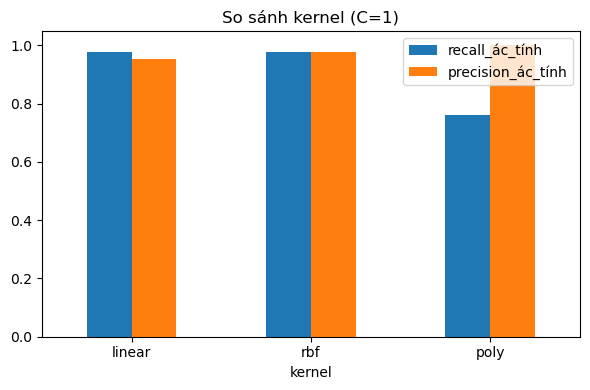

In [9]:
kernel_results = []
for k in ['linear', 'rbf', 'poly']:
    pipe_k = Pipeline([
        ('scale', StandardScaler()),
        ('svm', SVC(kernel=k, C=1, probability=False, random_state=RANDOM_STATE))
    ])
    pipe_k.fit(X_train, y_train)
    pred_k = pipe_k.predict(X_test)
    kernel_results.append({
        'kernel': k,
        'recall_ác_tính': recall_score(y_test, pred_k, pos_label=0),
        'precision_ác_tính': precision_score(y_test, pred_k, pos_label=0),
        'n_support_vectors': int(pipe_k.named_steps['svm'].n_support_.sum())
    })

kernel_df = pd.DataFrame(kernel_results).set_index('kernel')
print(kernel_df)

kernel_df[['recall_ác_tính', 'precision_ác_tính']].plot(kind='bar', rot=0)
plt.title("So sánh kernel (C=1)")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "kernel_comparison.png", dpi=120)
plt.show()

## Bước 7 — GridSearchCV dò C, gamma, kernel

 Dùng `scoring='recall'` (hoặc `make_scorer(recall_score, pos_label=0)`)
**thuần tuý** là sai — một mô hình luôn dự đoán "ác tính" cho mọi ca đạt
**recall = 1.0** dù vô dụng trên lâm sàng (precision rất thấp), nên GridSearch
tối ưu recall thuần có thể chọn ra cấu hình gần như luôn đoán ác tính mà không
bị phạt. Ô dưới đây **chứng minh** vấn đề bằng một `DummyClassifier` "luôn đoán
ác tính", rồi dùng **`fbeta_score(beta=2)`** (đặt trọng số recall cao hơn
precision, nhưng vẫn phạt precision quá thấp) làm scorer chính thức cho
GridSearch, thay vì recall thuần.

In [10]:
# Baseline "ngu": luôn đoán ác tính -> recall hoàn hảo nhưng vô dụng
dummy = DummyClassifier(strategy='constant', constant=0)
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)
print("DUMMY (luôn đoán ác tính) — recall:", recall_score(y_test, pred_dummy, pos_label=0),
      " precision:", round(precision_score(y_test, pred_dummy, pos_label=0), 3))
print("=> recall thuần túy KHÔNG phân biệt được mô hình này với một mô hình tốt thật sự.")
print("   Do đó KHÔNG dùng recall thuần làm scoring cho GridSearchCV.\n")

recall_malignant = make_scorer(recall_score, pos_label=0)          # chỉ dùng để MINH HOẠ vấn đề
fbeta2_malignant = make_scorer(fbeta_score, beta=2, pos_label=0)   # dùng làm scoring THẬT SỰ

pipe_gs = Pipeline([
    ('scale', StandardScaler()),
    ('svm', SVC(probability=True, class_weight='balanced', random_state=RANDOM_STATE))
])

param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.001, 0.01, 0.1],
    'svm__kernel': ['linear', 'rbf', 'poly']
}

gs = GridSearchCV(pipe_gs, param_grid, cv=5, scoring=fbeta2_malignant, n_jobs=-1)
gs.fit(X_train, y_train)

print("Best params (theo F2, ưu tiên recall nhưng có ràng buộc precision):", gs.best_params_)
print("Best CV F2(ác tính):", round(gs.best_score_, 3))

best_model = gs.best_estimator_
pred_best = best_model.predict(X_test)
print("Test recall(ác tính):", round(recall_score(y_test, pred_best, pos_label=0), 3))
print("Test precision(ác tính):", round(precision_score(y_test, pred_best, pos_label=0), 3))

DUMMY (luôn đoán ác tính) — recall: 1.0  precision: 0.368
=> recall thuần túy KHÔNG phân biệt được mô hình này với một mô hình tốt thật sự.
   Do đó KHÔNG dùng recall thuần làm scoring cho GridSearchCV.

Best params (theo F2, ưu tiên recall nhưng có ràng buộc precision): {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV F2(ác tính): 0.969
Test recall(ác tính): 0.976
Test precision(ác tính): 0.932


## Bước 8 — Heatmap điểm CV theo (C, gamma) — kernel RBF

Dựng từ `gs.cv_results_` (điểm chéo hoá CV trên tập **train**), không phải từ tập test — đúng cách để chọn siêu tham số mà không nhìn vào test.

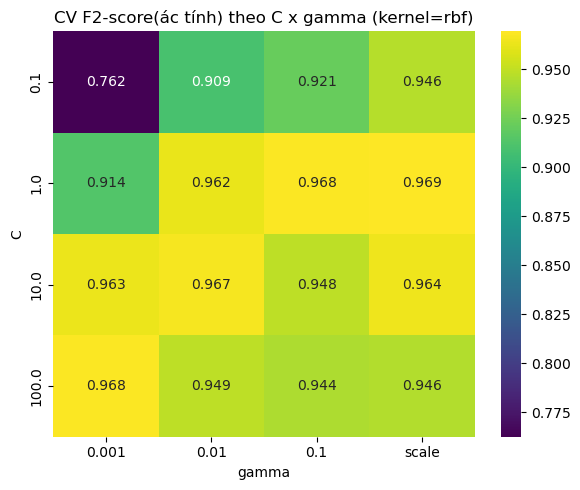

In [13]:
results = pd.DataFrame(gs.cv_results_)
rbf_results = results[results['param_svm__kernel'] == 'rbf'].copy()

# gamma có cả dạng số và 'scale' -> ép về string để làm trục pivot
rbf_results['gamma_str'] = rbf_results['param_svm__gamma'].astype(str)
rbf_results['C_str'] = rbf_results['param_svm__C'].astype(str)

pivot = rbf_results.pivot_table(index='C_str', columns='gamma_str',
                                 values='mean_test_score')
# sắp xếp trục C theo giá trị số
pivot = pivot.reindex(sorted(pivot.index, key=float))

plt.figure(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis')
plt.title("CV F2-score(ác tính) theo C x gamma (kernel=rbf)")
plt.xlabel("gamma")
plt.ylabel("C")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "C_gamma_heatmap.png", dpi=120)
plt.show()

## Bước 9 — Đếm support vectors của model tốt nhất

In [12]:
svm_best = best_model.named_steps['svm']
n_sv = svm_best.n_support_.sum()
pct_sv = n_sv / len(X_train) * 100

print("Số support vectors mỗi lớp:", dict(zip(target_names, svm_best.n_support_)))
print(f"Tổng support vectors: {n_sv} / {len(X_train)} mẫu train ({pct_sv:.1f}%)")

Số support vectors mỗi lớp: {'malignant': np.int32(49), 'benign': np.int32(59)}
Tổng support vectors: 108 / 455 mẫu train (23.7%)


**Giải thích:** SVM chỉ dùng các điểm nằm sát (hoặc vi phạm) lề để xác định
đường phân chia — các điểm nằm xa lề, ở "vùng an toàn" của lớp mình, không ảnh
hưởng đến kết quả huấn luyện dù có thay đổi hay xoá đi. Đó là lý do gọi chúng là
"support vectors": chúng là những điểm duy nhất "chống đỡ" ranh giới quyết định.

## Bước 10 — Chọn ngưỡng xác suất, KHÔNG dò trên tập test

Dò ngưỡng trực tiếp trên tập test rồi báo cáo
recall/FN đo được **trên chính tập đó** là rò rỉ dữ liệu (data leakage) — con số
thu được là *đã tối ưu cho test*, không phải ước lượng khách quan về khả năng
tổng quát hoá. Ở đây ngưỡng được chọn bằng xác suất **out-of-fold** lấy từ
`cross_val_predict` trên **tập train** (mô hình không nhìn thấy nhãn thật của
mẫu nó đang dự đoán trong mỗi fold). Tập test chỉ được dùng **một lần duy nhất**,
ở bước cuối, để đánh giá.

In [15]:
# Xác suất out-of-fold trên TRAIN (không đụng vào test)
oof_proba = cross_val_predict(best_model, X_train, y_train, cv=5, method='predict_proba')[:, 0]

thresholds = np.arange(0.05, 0.55, 0.01)
rows = []
for t in thresholds:
    pred_t = np.where(oof_proba >= t, 0, 1)  # proba(ác tính) >= t -> dự đoán ác tính (0)
    rec = recall_score(y_train, pred_t, pos_label=0)
    prec = precision_score(y_train, pred_t, pos_label=0)
    rows.append({'threshold': t, 'recall_ác_tính': rec, 'precision_ác_tính': prec})

threshold_df = pd.DataFrame(rows)
candidates = threshold_df[threshold_df['recall_ác_tính'] >= 0.98]
chosen = candidates.sort_values('precision_ác_tính', ascending=False).iloc[0] \
         if len(candidates) else threshold_df.sort_values('recall_ác_tính', ascending=False).iloc[0]

print("Ngưỡng được chọn (dựa trên OOF của TRAIN):", round(chosen['threshold'], 2))
print("Recall(ác tính) OOF tại ngưỡng này:", round(chosen['recall_ác_tính'], 3))
print("Precision(ác tính) OOF tại ngưỡng này:", round(chosen['precision_ác_tính'], 3))

# Áp ngưỡng đã chọn lên TEST — LẦN DUY NHẤT dùng test trong bước chọn ngưỡng
proba_test = best_model.predict_proba(X_test)[:, 0]
final_pred = np.where(proba_test >= chosen['threshold'], 0, 1)

final_recall = recall_score(y_test, final_pred, pos_label=0)
final_precision = precision_score(y_test, final_pred, pos_label=0)
print()
print("=> Recall(ác tính) THỰC TẾ trên test (ước lượng trung thực):", round(final_recall, 3))
print("=> Precision(ác tính) THỰC TẾ trên test:", round(final_precision, 3))
print("(Nếu số này thấp hơn recall OOF ở trên, đó là chênh lệch tự nhiên giữa CV và")
print(" một lần hold-out — không phải lỗi. Đây mới là con số nên báo cáo.)")

Ngưỡng được chọn (dựa trên OOF của TRAIN): 0.4
Recall(ác tính) OOF tại ngưỡng này: 0.982
Precision(ác tính) OOF tại ngưỡng này: 0.96

=> Recall(ác tính) THỰC TẾ trên test (ước lượng trung thực): 0.976
=> Precision(ác tính) THỰC TẾ trên test: 0.891
(Nếu số này thấp hơn recall OOF ở trên, đó là chênh lệch tự nhiên giữa CV và
 một lần hold-out — không phải lỗi. Đây mới là con số nên báo cáo.)


## Bước 11 — Ma trận nhầm lẫn tại ngưỡng đã chọn (đánh giá một lần duy nhất trên test)

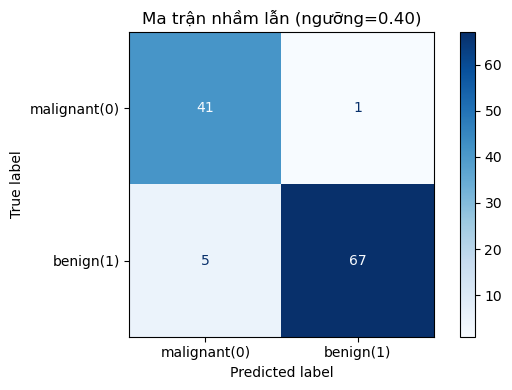

Số ca ÁC TÍNH bị bỏ sót (FN) trên test: 1 / 42 ca ác tính thực tế


In [16]:
cm = confusion_matrix(y_test, final_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(cm, display_labels=['malignant(0)', 'benign(1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Ma trận nhầm lẫn (ngưỡng={chosen['threshold']:.2f})")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "confusion_matrix.png", dpi=120)
plt.show()

fn = cm[0, 1]  # thực tế ác tính (hàng 0) nhưng dự đoán lành tính (cột 1)
print(f"Số ca ÁC TÍNH bị bỏ sót (FN) trên test: {fn} / {cm[0].sum()} ca ác tính thực tế")

## Bước 12 — So sánh với Logistic Regression (TT-04)

In [17]:
pipe_lr = Pipeline([
    ('scale', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=5000,
                               random_state=RANDOM_STATE))
])
pipe_lr.fit(X_train, y_train)
pred_lr = pipe_lr.predict(X_test)
proba_lr = pipe_lr.predict_proba(X_test)[:, 0]

summary = pd.DataFrame({
    'recall_ác_tính': [
        final_recall,
        recall_score(y_test, pred_lr, pos_label=0)
    ],
    'precision_ác_tính': [
        final_precision,
        precision_score(y_test, pred_lr, pos_label=0)
    ],
    'ROC_AUC': [
        roc_auc_score(1 - y_test, proba_test),
        roc_auc_score(1 - y_test, proba_lr)
    ]
}, index=['SVM (tuned + ngưỡng)', 'Logistic Regression'])

print(summary)

                      recall_ác_tính  precision_ác_tính   ROC_AUC
SVM (tuned + ngưỡng)         0.97619           0.891304  0.994048
Logistic Regression          0.97619           0.911111  0.995370


**Nhận xét:** trên bộ dữ liệu này, cả hai mô hình đạt hiệu năng khá gần
nhau vì các lớp tách bạch tốt. Logistic Regression có ưu thế là **giải thích
được** (hệ số cho biết mỗi đặc trưng ảnh hưởng thế nào), còn SVM (đặc biệt với
kernel phi tuyến) là hộp đen hơn nhưng có thể nắm bắt ranh giới cong tốt hơn
nếu dữ liệu không tách tuyến tính. Với bài toán y tế cần giải thích quyết định
cho bác sĩ, Logistic Regression thường được ưu tiên hơn khi hiệu năng tương đương.

## Lưu model và xuất số liệu

In [18]:
import json

joblib.dump(best_model, MODELS_DIR / "svm_pipeline.joblib")
print("Đã lưu model vào", MODELS_DIR / "svm_pipeline.joblib")

metrics = {
    "no_scale": {"recall": round(recall_noscale, 4), "precision": round(precision_noscale, 4)},
    "with_scale": {"recall": round(recall_scale, 4), "precision": round(precision_scale, 4)},
    "kernels": kernel_df.reset_index().to_dict(orient="records"),
    "grid_search_best_params": gs.best_params_,
    "grid_search_best_cv_f2": round(gs.best_score_, 4),
    "support_vectors": {"per_class": dict(zip(target_names, [int(x) for x in svm_best.n_support_])),
                         "total": int(n_sv), "train_size": int(len(X_train)),
                         "pct": round(pct_sv, 2)},
    "chosen_threshold": round(float(chosen['threshold']), 2),
    "threshold_selected_on": "out-of-fold predictions on TRAIN (cross_val_predict), not test",
    "final_test_recall_ác_tính": round(final_recall, 4),
    "final_test_precision_ác_tính": round(final_precision, 4),
    "false_negatives_on_test": int(fn),
    "malignant_in_test": int(cm[0].sum()),
    "logistic_regression_comparison": summary.reset_index().rename(columns={'index': 'model'}).to_dict(orient="records"),
}

with open(REPORTS_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print("Đã ghi số liệu vào", REPORTS_DIR / "metrics.json")

Đã lưu model vào d:\Tai_lieu_hoc_AI\NOP_BAI_LAB_ML\Hoc may\01- Phan loai\TT - 05\models\svm_pipeline.joblib
Đã ghi số liệu vào d:\Tai_lieu_hoc_AI\NOP_BAI_LAB_ML\Hoc may\01- Phan loai\TT - 05\reports\metrics.json
